## **Emotion Detection System**

In [1]:
!kaggle datasets download -d shawon10/ckplus

Dataset URL: https://www.kaggle.com/datasets/shawon10/ckplus
License(s): CC0-1.0
100% 3.63M/3.63M [00:00<00:00, 66.9MB/s]



In [2]:
import zipfile
zip_ref=zipfile.ZipFile('/content/ckplus.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [9]:
import shutil
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras import optimizers
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [4]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=5,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True
)

In [5]:
training_data = train_datagen.flow_from_directory(
    '/content/ck/CK+48',
    target_size=(96,96),
    batch_size=32,
    color_mode='rgb',
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

Found 788 images belonging to 7 classes.


In [6]:
testing_data = train_datagen.flow_from_directory(
    '/content/ck/CK+48',
    target_size=(96,96),
    batch_size=32,
    color_mode='rgb',
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

Found 193 images belonging to 7 classes.


In [7]:
print(training_data.class_indices)
print(testing_data.class_indices)

{'anger': 0, 'contempt': 1, 'disgust': 2, 'fear': 3, 'happy': 4, 'sadness': 5, 'surprise': 6}
{'anger': 0, 'contempt': 1, 'disgust': 2, 'fear': 3, 'happy': 4, 'sadness': 5, 'surprise': 6}


Creating CNN Architecture from scratch

In [ ]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu', padding='same' input_shape=(48,48,1)))
model.add(BatchNormalization())
model.add(MaxPooling2D())

model.add(Conv2D(64,(3,3),activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D())

model.add(Conv2D(128,(3,3),activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D())

model.add(GlobalAveragePooling2D())

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(7, activation='softmax'))

In [ ]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
early_stoping = EarlyStopping(monitor='val_accuracy', min_delta=0.00005, patience=11, verbose=1, restore_best_weights=True)

In [ ]:
model.fit(training_data, epochs=50, validation_data=testing_data, callbacks=[early_stoping])

It is not working well because our data size is too small to train a neural network, So now we will try pretrain CNN model "MobileNetV2".

In [10]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(96,96,3))

base_model.trainable = False

model = Sequential()

model.add(base_model)

model.add(GlobalAveragePooling2D())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.3))

model.add(Dense(7, activation='softmax'))

In [11]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [12]:
early_stoping = EarlyStopping(monitor='val_accuracy', min_delta=0.00005, patience=11, verbose=1, restore_best_weights=True)

In [13]:
history = model.fit(training_data, epochs=50, validation_data=testing_data, callbacks=[early_stoping])

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 22s 605ms/step - accuracy: 0.2373 - loss: 2.1769 - val_accuracy: 0.4456 - val_loss: 1.6377
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 23s 722ms/step - accuracy: 0.4239 - loss: 1.6654 - val_accuracy: 0.4767 - val_loss: 1.4481
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 606ms/step - accuracy: 0.4911 - loss: 1.4445 - val_accuracy: 0.5492 - val_loss: 1.3353
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 413ms/step - accuracy: 0.5444 - loss: 1.3264 - val_accuracy: 0.5803 - val_loss: 1.2468
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 351ms/step - accuracy: 0.5964 - loss: 1.2066 - val_accuracy: 0.6062 - val_loss: 1.2135
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 400ms/step - accuracy: 0.5964 - loss: 1.1437 - val_accuracy: 0.6269 - val_loss: 1.1347
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 491ms/step - accuracy: 0.6548 - loss: 1.0377 - val_accuracy: 0.6062 - val_loss: 1.0620
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 440ms/step - accuracy: 0.6688 - loss: 0.9703 - val_accur

In [14]:
loss, accuracy = model.evaluate(testing_data)

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 218ms/step - accuracy: 0.7409 - loss: 0.7073


In [15]:
print(f'Validation Loss: {loss}')
print(f'Validation Accuracy: {accuracy * 100:.2f}%')

Validation Loss: 0.7073487639427185
Validation Accuracy: 74.09%


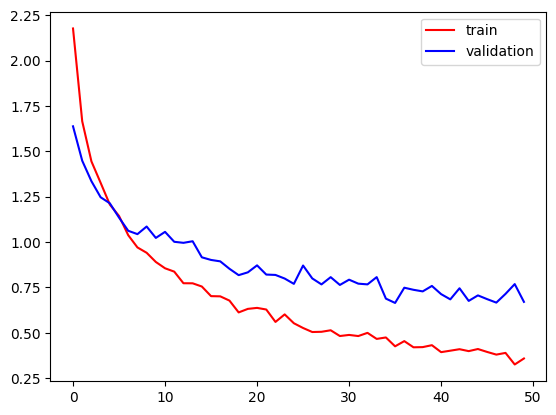

In [16]:
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.legend()

In [17]:
predictions = model.predict(testing_data)

y_pred = np.argmax(predictions, axis=1)
y_true = testing_data.classes

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 428ms/step


In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=list(testing_data.class_indices.keys())))

              precision    recall  f1-score   support

       anger       0.74      0.63      0.68        27
    contempt       1.00      0.20      0.33        10
     disgust       0.83      0.97      0.89        35
        fear       0.91      0.67      0.77        15
       happy       0.78      0.93      0.84        41
     sadness       0.39      0.44      0.41        16
    surprise       0.96      0.96      0.96        49

    accuracy                           0.80       193
   macro avg       0.80      0.68      0.70       193
weighted avg       0.82      0.80      0.79       193



Testing on Real World Data

In [19]:
import cv2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [20]:
test_img = cv2.imread('/content/anger3.jpeg')

test_img = cv2.resize(test_img, (96,96))

test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)

test_input = np.array(test_img, dtype=np.float32)

test_input = preprocess_input(test_input)

test_input = np.expand_dims(test_input, axis=0)

In [21]:
prediction = model.predict(test_input)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
[[5.6706548e-01 1.1800491e-03 4.1107577e-01 2.6980122e-03 1.1594542e-04
  1.0589572e-02 7.2751842e-03]]
